In [1]:
import os, shutil, random, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


2026-04-11 04:21:02.456936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775881262.654179      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775881262.708884      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775881263.144081      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775881263.144128      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775881263.144131      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 🍃 Leaf Disease Detection — Component-Wise Training
Run each section **independently**. Already-completed stages are auto-skipped.
- **Stage 0** — Imports & Config  
- **Stage 1A** — Create Validator Dataset  
- **Stage 1B** — Train Leaf Validator  
- **Stage 2A** — Create Disease Dataset  
- **Stage 2B** — Train Disease Classifier  


In [2]:
class Config:
    BASE_PATH  = "/kaggle/input/datasets/dp2302/leaf-final/Dataset"
    LEAF_PATH     = os.path.join(BASE_PATH, "Leaf")
    LEAF_NEW_PATH = os.path.join(BASE_PATH, "Leaf_New")
    NON_LEAF_PATH = os.path.join(BASE_PATH, "Non Leaf")
    WORKING_PATH  = "/kaggle/working"

    VALIDATOR_IMG_SIZE   = (224, 224)
    VALIDATOR_BATCH_SIZE = 32
    VALIDATOR_EPOCHS     = 20
    VALIDATOR_LR         = 1e-3

    DISEASE_IMG_SIZE        = (240, 240)
    DISEASE_BATCH_SIZE      = 32
    DISEASE_EPOCHS_INITIAL  = 15
    DISEASE_EPOCHS_FINETUNE = 10
    DISEASE_LR_INITIAL      = 1e-3
    DISEASE_LR_FINETUNE     = 1e-5

    TRAIN_SPLIT  = 0.8
    RANDOM_STATE = 42

config = Config()

if not os.path.exists(config.BASE_PATH):
    print(f"❌ Dataset not found at {config.BASE_PATH}")
    print("Update BASE_PATH in Config to match your Kaggle dataset path.")
else:
    print("✅ Config OK — dataset found")


✅ Config OK — dataset found


## 🛠️ Helper Functions (run once)

In [3]:
# ─────────────────────────────────────────────
# FIX: Filter out corrupt / non-image files
# ─────────────────────────────────────────────
import struct

VALID_MAGIC = {
    b"\xff\xd8\xff": "JPEG",
    b"\x89PNG":       "PNG",
    b"GIF8":          "GIF",
    b"BM":            "BMP",
}

def is_valid_image(path):
    """Return True only if the file starts with a known image magic bytes."""
    try:
        with open(path, "rb") as f:
            header = f.read(8)
        for magic in VALID_MAGIC:
            if header.startswith(magic):
                return True
        return False
    except Exception:
        return False


def collect_images(folder, extensions=(".png", ".jpg", ".jpeg", ".bmp", ".gif")):
    """Collect image paths, skipping corrupt files."""
    valid, skipped = [], []
    for fname in os.listdir(folder):
        if fname.lower().endswith(extensions):
            full = os.path.join(folder, fname)
            if is_valid_image(full):
                valid.append(full)
            else:
                skipped.append(fname)
    if skipped:
        print(f"  ⚠️  Skipped {len(skipped)} corrupt files in {os.path.basename(folder)}")
    return valid


def load_dataset(path, img_size, batch_size, augment=False, preprocessing_fn=None):
    """Load dataset from directory with optional augmentation."""
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
        layers.RandomBrightness(0.2),
    ], name="data_augmentation")

    train_path = os.path.join(path, "train")
    num_classes = len([d for d in os.listdir(train_path)
                       if os.path.isdir(os.path.join(train_path, d))])

    label_mode = "categorical" if num_classes > 2 else "binary"

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_path, image_size=img_size, batch_size=batch_size,
        label_mode=label_mode, shuffle=True, seed=Config.RANDOM_STATE)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(path, "val"), image_size=img_size, batch_size=batch_size,
        label_mode=label_mode, shuffle=False, seed=Config.RANDOM_STATE)

    class_names = train_ds.class_names

    def preprocess_batch(images, labels):
        if augment:
            images = data_augmentation(images, training=True)
        if preprocessing_fn is not None:
            images = preprocessing_fn(images)
        return images, labels

    train_ds = train_ds.map(preprocess_batch, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds   = val_ds.map(
        lambda x, y: (preprocessing_fn(x) if preprocessing_fn else x, y),
        num_parallel_calls=tf.data.AUTOTUNE)

    train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, class_names


def compute_class_weights_from_dataset(dataset):
    """Compute balanced class weights."""
    labels = []
    for _, label_batch in dataset:
        if len(label_batch.shape) > 1:
            labels.extend(np.argmax(label_batch.numpy(), axis=1))
        else:
            labels.extend(label_batch.numpy())
    labels  = np.array(labels)
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw = dict(zip(classes, weights))
    print("\n📊 Class weights:")
    for c, w in cw.items():
        print(f"  Class {c}: {w:.2f}")
    return cw


def get_callbacks(model_name, config):
    checkpoint_path = os.path.join(config.WORKING_PATH, f"{model_name}_best.keras")
    return [
        ModelCheckpoint(checkpoint_path, monitor="val_accuracy",
                        save_best_only=True, mode="max", verbose=1),
        EarlyStopping(monitor="val_loss", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
    ]


def unfreeze_and_finetune(model, num_layers_to_unfreeze, learning_rate):
    print(f"\n🔓 Unfreezing last {num_layers_to_unfreeze} layers...")
    base_model = next((l for l in model.layers if isinstance(l, keras.Model)), None)
    if base_model is None:
        print("⚠️  Base model not found"); return model
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=model.loss, metrics=model.metrics)
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"✓ Trainable params: {trainable:,}")
    return model


def evaluate_model(model, dataset, class_names, model_name):
    print("\n" + "="*70)
    print(f"Evaluating {model_name}")
    print("="*70)
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        if len(preds.shape) > 1 and preds.shape[1] > 1:
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(np.argmax(labels.numpy(), axis=1))
        else:
            y_pred.extend((preds > 0.5).astype(int).flatten())
            y_true.extend(labels.numpy().astype(int))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
    print("\n📊 Classification Report:\n" + "="*70)
    print(report)
    with open(os.path.join(Config.WORKING_PATH, f"{model_name}_report.txt"), "w") as f:
        f.write(report)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(10, len(class_names)), max(8, len(class_names)*0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} — Confusion Matrix", fontsize=16, fontweight="bold")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(os.path.join(Config.WORKING_PATH, f"{model_name}_confusion_matrix.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    acc = np.mean(y_true == y_pred)
    print(f"\n✅ Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    return acc, report

print("✅ All helper functions loaded")


✅ All helper functions loaded


---
## 🔷 Stage 1A — Create Leaf Validator Dataset
**Skip logic:** If `/kaggle/working/leaf_validator` already exists with correct structure, this cell will skip copying and reuse it.


In [4]:
VALIDATOR_PATH = os.path.join(config.WORKING_PATH, "leaf_validator")
_DONE_FLAG     = os.path.join(VALIDATOR_PATH, ".done")

if os.path.exists(_DONE_FLAG):
    print("⏭️  Validator dataset already created — skipping.")
    print(f"📁 Reusing: {VALIDATOR_PATH}")
else:
    print("\n" + "="*70)
    print("STEP 1: Creating Leaf Validator Dataset")
    print("="*70)

    for split in ["train", "val"]:
        for cls in ["leaf", "non_leaf"]:
            os.makedirs(os.path.join(VALIDATOR_PATH, split, cls), exist_ok=True)

    # ── Collect LEAF images (Source 1: Leaf folder) ──
    print("\n📂 Collecting LEAF images...")
    all_leaf = []

    print("\n🌿 Source 1: Leaf folder (disease subfolders)")
    if os.path.exists(config.LEAF_PATH):
        for folder in sorted(os.listdir(config.LEAF_PATH)):
            fp = os.path.join(config.LEAF_PATH, folder)
            if os.path.isdir(fp):
                imgs = collect_images(fp)
                all_leaf.extend(imgs)
                print(f"  ✓ {folder}: {len(imgs)} images")
    else:
        print(f"  ⚠️  {config.LEAF_PATH} not found")

    src1_count = len(all_leaf)
    print(f"\n  📊 Source 1 subtotal: {src1_count}")

    # ── Source 2: Leaf_New ──
    print("\n🌿 Source 2: Leaf_New folder")
    src2_count = 0
    if os.path.exists(config.LEAF_NEW_PATH):
        for folder in sorted(os.listdir(config.LEAF_NEW_PATH)):
            fp = os.path.join(config.LEAF_NEW_PATH, folder)
            if os.path.isdir(fp):
                imgs = collect_images(fp)
                all_leaf.extend(imgs)
                src2_count += len(imgs)
                print(f"  ✓ {folder}: {len(imgs)} images")
    else:
        print(f"  ⚠️  {config.LEAF_NEW_PATH} not found")

    print(f"\n  📊 Source 2 subtotal: {src2_count}")
    print(f"\n✅ TOTAL LEAF images: {len(all_leaf)}")

    # ── Split & Copy LEAF ──
    random.shuffle(all_leaf)
    split_idx   = int(config.TRAIN_SPLIT * len(all_leaf))
    train_leaf  = all_leaf[:split_idx]
    val_leaf    = all_leaf[split_idx:]

    print("\n📋 Copying leaf images...")
    for img in train_leaf:
        shutil.copy(img, os.path.join(VALIDATOR_PATH, "train", "leaf"))
    for img in val_leaf:
        shutil.copy(img, os.path.join(VALIDATOR_PATH, "val", "leaf"))
    print(f"  ✓ Train leaf: {len(train_leaf)}")
    print(f"  ✓ Val   leaf: {len(val_leaf)}")

    # ── Collect & copy NON-LEAF ──
    print("\n📂 Processing NON-LEAF images...")
    all_non_leaf = []
    if os.path.exists(config.NON_LEAF_PATH):
        for fname in os.listdir(config.NON_LEAF_PATH):
            fp = os.path.join(config.NON_LEAF_PATH, fname)
            if os.path.isfile(fp) and is_valid_image(fp):
                all_non_leaf.append(fp)
        # Also check subfolders
        for folder in os.listdir(config.NON_LEAF_PATH):
            fp = os.path.join(config.NON_LEAF_PATH, folder)
            if os.path.isdir(fp):
                all_non_leaf.extend(collect_images(fp))
    else:
        print(f"  ⚠️  {config.NON_LEAF_PATH} not found")

    random.shuffle(all_non_leaf)
    split_nl       = int(config.TRAIN_SPLIT * len(all_non_leaf))
    train_non_leaf = all_non_leaf[:split_nl]
    val_non_leaf   = all_non_leaf[split_nl:]

    for img in train_non_leaf:
        shutil.copy(img, os.path.join(VALIDATOR_PATH, "train", "non_leaf"))
    for img in val_non_leaf:
        shutil.copy(img, os.path.join(VALIDATOR_PATH, "val", "non_leaf"))
    print(f"  ✓ Train non-leaf: {len(train_non_leaf)}")
    print(f"  ✓ Val   non-leaf: {len(val_non_leaf)}")

    # ── Summary ──
    print("\n" + "="*70)
    print("VALIDATOR DATASET SUMMARY")
    print("="*70)
    print(f"Total Leaf:     {len(all_leaf)}  (Source1: {src1_count}, Source2: {src2_count})")
    print(f"Total Non-Leaf: {len(all_non_leaf)}")
    print(f"Train: {len(train_leaf)+len(train_non_leaf)}  |  Val: {len(val_leaf)+len(val_non_leaf)}")
    print("="*70)

    # Mark done
    Path(_DONE_FLAG).touch()
    print(f"\n✅ Validator dataset created at {VALIDATOR_PATH}")



STEP 1: Creating Leaf Validator Dataset

📂 Collecting LEAF images...

🌿 Source 1: Leaf folder (disease subfolders)
  ✓ banana__leaf__disease__black_leaf_streak: 63 images
  ✓ banana__leaf__disease__black_sigatoka: 237 images
  ✓ banana__leaf__disease__panama: 97 images
  ✓ banana__leaf__disease__scab_moth: 19 images
  ✓ banana__leaf__healthy: 1342 images
  ✓ guava__leaf__disease__anthracnose: 237 images
  ✓ guava__leaf__disease__canker: 192 images
  ✓ guava__leaf__disease__dot: 219 images
  ✓ guava__leaf__disease__rust: 167 images
  ✓ guava__leaf__healthy: 1248 images
  ✓ mango__leaf__disease__anthracnose: 326 images
  ✓ mango__leaf__disease__bacterial_canker: 360 images
  ✓ mango__leaf__disease__cutting_weevil: 307 images
  ✓ mango__leaf__disease__die_back: 320 images
  ✓ mango__leaf__disease__gall_midge: 319 images
  ✓ mango__leaf__disease__powdery_mildew: 206 images
  ✓ mango__leaf__disease__sooty_mould: 265 images
  ✓ mango__leaf__healthy: 250 images
  ✓ papaya__leaf__disease__ant

---
## 🔷 Stage 1B — Build & Train Leaf Validator Model
**Skip logic:** If `leaf_validator_final.keras` already exists, training is skipped.


⏭️  Validator model already trained — loading from disk.
Found 15215 files belonging to 2 classes.
Found 4133 files belonging to 2 classes.
✓ Classes: ['leaf', 'non_leaf']

Evaluating Leaf_Validator

📊 Classification Report:
              precision    recall  f1-score   support

        leaf      0.914     0.934     0.924      3043
    non_leaf      0.804     0.755     0.779      1090

    accuracy                          0.887      4133
   macro avg      0.859     0.844     0.851      4133
weighted avg      0.885     0.887     0.886      4133



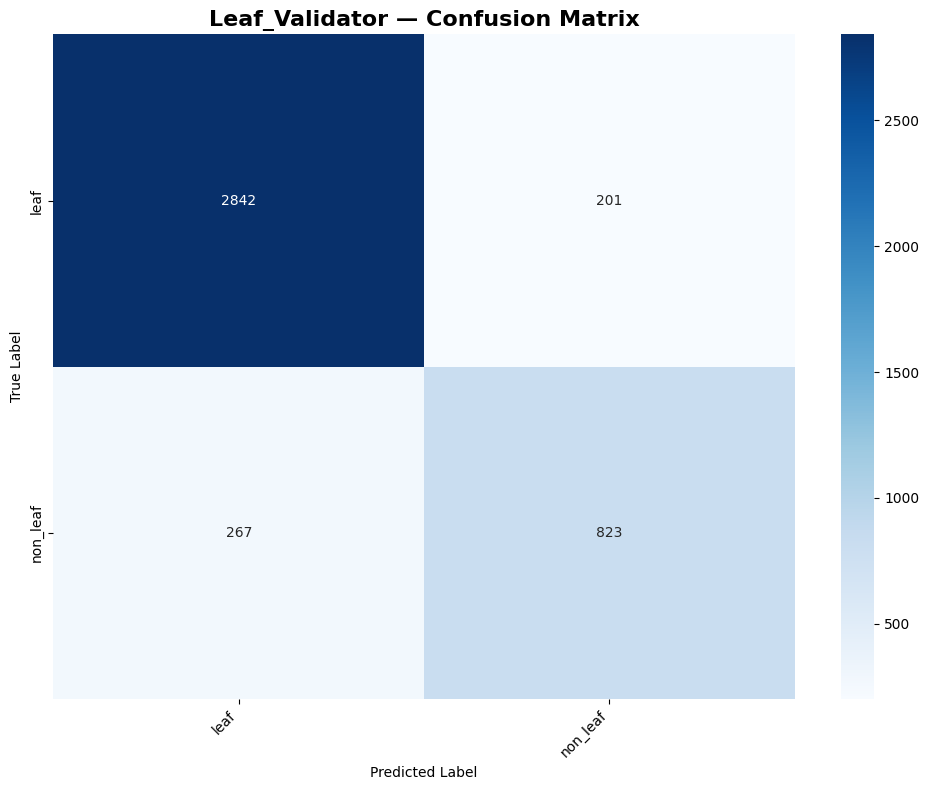


✅ Accuracy: 0.6192 (61.92%)

🎯 Validator Accuracy: 61.92%


In [9]:
def build_leaf_validator_model(config):
    print("\n" + "="*70)
    print("Building Leaf Validator Model (Binary Classification)")
    print("="*70)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*config.VALIDATOR_IMG_SIZE, 3), include_top=False, weights="imagenet")
    base_model.trainable = False

    inputs = keras.Input(shape=(*config.VALIDATOR_IMG_SIZE, 3))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="validator_output")(x)

    model = keras.Model(inputs, outputs, name="leaf_validator")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.VALIDATOR_LR),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall"),
                 keras.metrics.AUC(name="auc")])
    print(f"\u2713 Model built \u2014 Total params: {model.count_params():,}")
    return model


def unfreeze_validator(model, num_layers, learning_rate):
    """
    FIX: Recompile with FRESH metric objects to avoid
    'multiple values for argument sample_weight' TypeError in Keras 3.
    """
    print(f"\n\U0001f513 Unfreezing last {num_layers} layers...")
    base_model = next((l for l in model.layers if isinstance(l, keras.Model)), None)
    if base_model is None:
        print("\u26a0\ufe0f  Base model not found"); return model

    base_model.trainable = True
    for layer in base_model.layers[:-num_layers]:
        layer.trainable = False

    # KEY FIX: fresh metric instances — reusing old ones causes TypeError
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall"),
                 keras.metrics.AUC(name="auc")])

    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"\u2713 Trainable params: {trainable:,}")
    return model


def plot_training_history(h1, h2=None, model_name="Model"):
    """Plot train vs val accuracy & loss for overfitting check."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} \u2014 Training History", fontsize=14, fontweight="bold")

    acc      = h1.history["accuracy"]
    val_acc  = h1.history["val_accuracy"]
    loss     = h1.history["loss"]
    val_loss = h1.history["val_loss"]
    phase1_end = len(acc)

    if h2 is not None:
        acc      += h2.history["accuracy"]
        val_acc  += h2.history["val_accuracy"]
        loss     += h2.history["loss"]
        val_loss += h2.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    # Accuracy
    axes[0].plot(epochs, acc,     "b-o", markersize=3, label="Train Acc")
    axes[0].plot(epochs, val_acc, "r-o", markersize=3, label="Val Acc")
    if h2 is not None:
        axes[0].axvline(phase1_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune starts")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)

    # Loss
    axes[1].plot(epochs, loss,     "b-o", markersize=3, label="Train Loss")
    axes[1].plot(epochs, val_loss, "r-o", markersize=3, label="Val Loss")
    if h2 is not None:
        axes[1].axvline(phase1_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune starts")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(Config.WORKING_PATH, f"{model_name}_training_history.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n\U0001f4ca Training history saved \u2192 {save_path}")

    # Overfitting summary
    final_gap = val_acc[-1] - acc[-1]
    status = "\u2705 OK" if abs(final_gap) < 0.08 else ("\u26a0\ufe0f Possible overfit" if final_gap < -0.08 else "\u26a0\ufe0f Val > Train")
    print(f"\n\U0001f50d Overfitting check (last epoch):")
    print(f"   Train Acc : {acc[-1]:.4f}")
    print(f"   Val Acc   : {val_acc[-1]:.4f}")
    print(f"   Gap       : {final_gap:+.4f}  {status}")


# ─────────────────────────────────────────────────────────────────────────────
_VALIDATOR_MODEL_PATH = os.path.join(config.WORKING_PATH, "leaf_validator_final.keras")

if os.path.exists(_VALIDATOR_MODEL_PATH):
    print("\u23ed\ufe0f  Validator model already trained \u2014 loading from disk.")
    validator_model = keras.models.load_model(_VALIDATOR_MODEL_PATH)
    validator_train, validator_val, validator_classes = load_dataset(
        VALIDATOR_PATH, config.VALIDATOR_IMG_SIZE, config.VALIDATOR_BATCH_SIZE,
        augment=False,
        preprocessing_fn=tf.keras.applications.mobilenet_v2.preprocess_input)
    print(f"\u2713 Classes: {validator_classes}")
else:
    print("\n\U0001f4e6 Loading validator datasets...")
    validator_train, validator_val, validator_classes = load_dataset(
        VALIDATOR_PATH, config.VALIDATOR_IMG_SIZE, config.VALIDATOR_BATCH_SIZE,
        augment=True,
        preprocessing_fn=tf.keras.applications.mobilenet_v2.preprocess_input)
    print(f"\u2713 Classes: {validator_classes}")
    print(f"\u2713 Train batches: {len(validator_train)}  |  Val batches: {len(validator_val)}")

    validator_model = build_leaf_validator_model(config)

    # Class weights from folder counts (avoids dataset iteration bug)
    train_leaf_count     = len(os.listdir(os.path.join(VALIDATOR_PATH, "train", "leaf")))
    train_non_leaf_count = len(os.listdir(os.path.join(VALIDATOR_PATH, "train", "non_leaf")))
    total = train_leaf_count + train_non_leaf_count
    class_weights_validator = {
        0: total / (2 * train_leaf_count),
        1: total / (2 * train_non_leaf_count),
    }
    print(f"\n\U0001f4ca Class weights (from folder counts):")
    print(f"  Class 0 (leaf):     {class_weights_validator[0]:.4f}  [{train_leaf_count} images]")
    print(f"  Class 1 (non_leaf): {class_weights_validator[1]:.4f}  [{train_non_leaf_count} images]")

    print("\n\U0001f680 Training validator model (Phase 1 \u2014 frozen base)...")
    history_v1 = validator_model.fit(
        validator_train, validation_data=validator_val,
        epochs=config.VALIDATOR_EPOCHS,
        callbacks=get_callbacks("leaf_validator", config),
        class_weight=class_weights_validator, verbose=1)

    print("\n\U0001f527 Fine-tuning validator model (Phase 2 \u2014 unfrozen)...")
    validator_model = unfreeze_validator(validator_model, 30, learning_rate=1e-5)
    history_v2 = validator_model.fit(
        validator_train, validation_data=validator_val,
        epochs=10,
        callbacks=get_callbacks("leaf_validator_finetuned", config),
        class_weight=class_weights_validator, verbose=1)

    # Plot training curves
    plot_training_history(history_v1, history_v2, model_name="Leaf_Validator")

    validator_model.save(_VALIDATOR_MODEL_PATH)
    print(f"\n\u2705 Validator model saved \u2192 {_VALIDATOR_MODEL_PATH}")

# Evaluate
val_accuracy, val_report = evaluate_model(
    validator_model, validator_val, validator_classes, "Leaf_Validator")
print(f"\n\U0001f3af Validator Accuracy: {val_accuracy*100:.2f}%")


---
## 🔶 Stage 2A — Create Disease Classification Dataset
**Skip logic:** If `/kaggle/working/disease_classifier` already exists, this cell skips.


In [8]:
DISEASE_PATH  = os.path.join(config.WORKING_PATH, "disease_classifier")
_DONE_FLAG_D  = os.path.join(DISEASE_PATH, ".done")

if os.path.exists(_DONE_FLAG_D):
    print("⏭️  Disease dataset already created — skipping.")
    print(f"📁 Reusing: {DISEASE_PATH}")
else:
    print("\n" + "="*70)
    print("STEP 2: Preparing Disease Classification Dataset")
    print("="*70)

    for split in ["train", "val"]:
        os.makedirs(os.path.join(DISEASE_PATH, split), exist_ok=True)

    if not os.path.exists(config.LEAF_PATH):
        raise FileNotFoundError(f"Leaf folder not found: {config.LEAF_PATH}")

    disease_classes = sorted([
        d for d in os.listdir(config.LEAF_PATH)
        if os.path.isdir(os.path.join(config.LEAF_PATH, d))
    ])
    print(f"✓ Found {len(disease_classes)} disease classes")

    for disease_class in disease_classes:
        src = os.path.join(config.LEAF_PATH, disease_class)
        imgs = collect_images(src)   # ← corrupt files filtered here

        random.shuffle(imgs)
        split_idx    = int(config.TRAIN_SPLIT * len(imgs))
        train_imgs   = imgs[:split_idx]
        val_imgs     = imgs[split_idx:]

        train_dir = os.path.join(DISEASE_PATH, "train", disease_class)
        val_dir   = os.path.join(DISEASE_PATH, "val",   disease_class)
        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir,   exist_ok=True)

        for img in train_imgs: shutil.copy(img, train_dir)
        for img in val_imgs:   shutil.copy(img, val_dir)
        print(f"  ✓ {disease_class}: {len(train_imgs)} train, {len(val_imgs)} val")

    Path(_DONE_FLAG_D).touch()
    print(f"\n✅ Disease dataset created at {DISEASE_PATH}")



STEP 2: Preparing Disease Classification Dataset
✓ Found 28 disease classes
  ✓ banana__leaf__disease__black_leaf_streak: 50 train, 13 val
  ✓ banana__leaf__disease__black_sigatoka: 189 train, 48 val
  ✓ banana__leaf__disease__panama: 77 train, 20 val
  ✓ banana__leaf__disease__scab_moth: 15 train, 4 val
  ✓ banana__leaf__healthy: 1073 train, 269 val
  ✓ guava__leaf__disease__anthracnose: 189 train, 48 val
  ✓ guava__leaf__disease__canker: 153 train, 39 val
  ✓ guava__leaf__disease__dot: 175 train, 44 val
  ✓ guava__leaf__disease__rust: 133 train, 34 val
  ✓ guava__leaf__healthy: 998 train, 250 val
  ✓ mango__leaf__disease__anthracnose: 260 train, 66 val
  ✓ mango__leaf__disease__bacterial_canker: 288 train, 72 val
  ✓ mango__leaf__disease__cutting_weevil: 245 train, 62 val
  ✓ mango__leaf__disease__die_back: 256 train, 64 val
  ✓ mango__leaf__disease__gall_midge: 255 train, 64 val
  ✓ mango__leaf__disease__powdery_mildew: 164 train, 42 val
  ✓ mango__leaf__disease__sooty_mould: 212 t

---
## 🔶 Stage 2B — Build & Train Disease Classifier
**Skip logic:** If `disease_classifier_final.keras` already exists, training is skipped.



📦 Loading disease datasets...
Found 8991 files belonging to 28 classes.
Found 2262 files belonging to 28 classes.
✓ Disease classes: 28
✓ Train batches: 281  |  Val batches: 71

Building Disease Classifier Model (28 classes)
✓ Model built — Total params: 7,374,755

📊 Class weights (from folder counts):
  Class  0 (banana__leaf__disease__black_leaf_streak): 6.4221  [50 images]
  Class  1 (banana__leaf__disease__black_sigatoka): 1.6990  [189 images]
  Class  2 (banana__leaf__disease__panama): 4.1702  [77 images]
  Class  3 (banana__leaf__disease__scab_moth): 21.4071  [15 images]
  Class  4 (banana__leaf__healthy): 0.2993  [1073 images]
  Class  5 (guava__leaf__disease__anthracnose): 1.6990  [189 images]
  Class  6 (guava__leaf__disease__canker): 2.0987  [153 images]
  Class  7 (guava__leaf__disease__dot): 1.8349  [175 images]
  Class  8 (guava__leaf__disease__rust): 2.4143  [133 images]
  Class  9 (guava__leaf__healthy): 0.3218  [998 images]
  Class 10 (mango__leaf__disease__anthracnose

2026-04-11 05:27:37.302456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:27:37.508508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:27:37.825224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:27:38.030938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:27:38.557877: E external/local_xla/xla/stream_

280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7393 - loss: 1.6207 - top_3_accuracy: 0.9236

2026-04-11 05:28:16.959891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:28:17.167345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:28:17.486681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:28:17.693883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 05:28:18.166885: E external/local_xla/xla/stream_

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7394 - loss: 1.6204 - top_3_accuracy: 0.9236
Epoch 1: val_accuracy improved from -inf to 0.82891, saving model to /kaggle/working/disease_classifier_finetuned_best.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 107s 216ms/step - accuracy: 0.7395 - loss: 1.6202 - top_3_accuracy: 0.9236 - val_accuracy: 0.8289 - val_loss: 1.3803 - val_top_3_accuracy: 0.9708 - learning_rate: 1.0000e-05
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7836 - loss: 1.4710 - top_3_accuracy: 0.9524
Epoch 2: val_accuracy improved from 0.82891 to 0.85102, saving model to /kaggle/working/disease_classifier_finetuned_best.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.7837 - loss: 1.4708 - top_3_accuracy: 0.9524 - val_accuracy: 0.8510 - val_loss: 1.3285 - val_top_3_accuracy: 0.9730 - learning_rate: 1.0000e-05
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8077 - loss: 1.3701 - top_3_accuracy: 0.9624
Epoch 3: val_accu

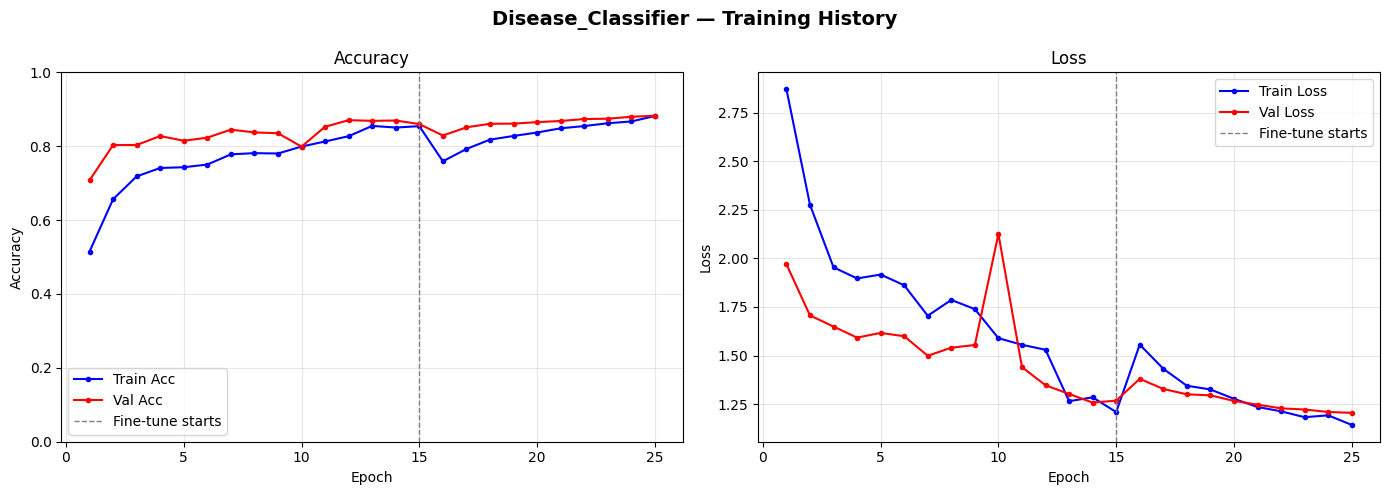


📊 Training history saved → /kaggle/working/Disease_Classifier_training_history.png

🔍 Overfitting check (last epoch):
   Train Acc : 0.8818
   Val Acc   : 0.8824
   Gap       : +0.0006  ✅ OK

✅ Disease model saved → /kaggle/working/disease_classifier_final.keras

Evaluating Disease_Classifier

📊 Classification Report:
                                          precision    recall  f1-score   support

banana__leaf__disease__black_leaf_streak      0.867     1.000     0.929        13
   banana__leaf__disease__black_sigatoka      0.886     0.812     0.848        48
           banana__leaf__disease__panama      0.615     0.800     0.696        20
        banana__leaf__disease__scab_moth      0.500     0.750     0.600         4
                   banana__leaf__healthy      0.996     0.985     0.991       269
       guava__leaf__disease__anthracnose      0.722     0.812     0.765        48
            guava__leaf__disease__canker      0.789     0.769     0.779        39
               guava__

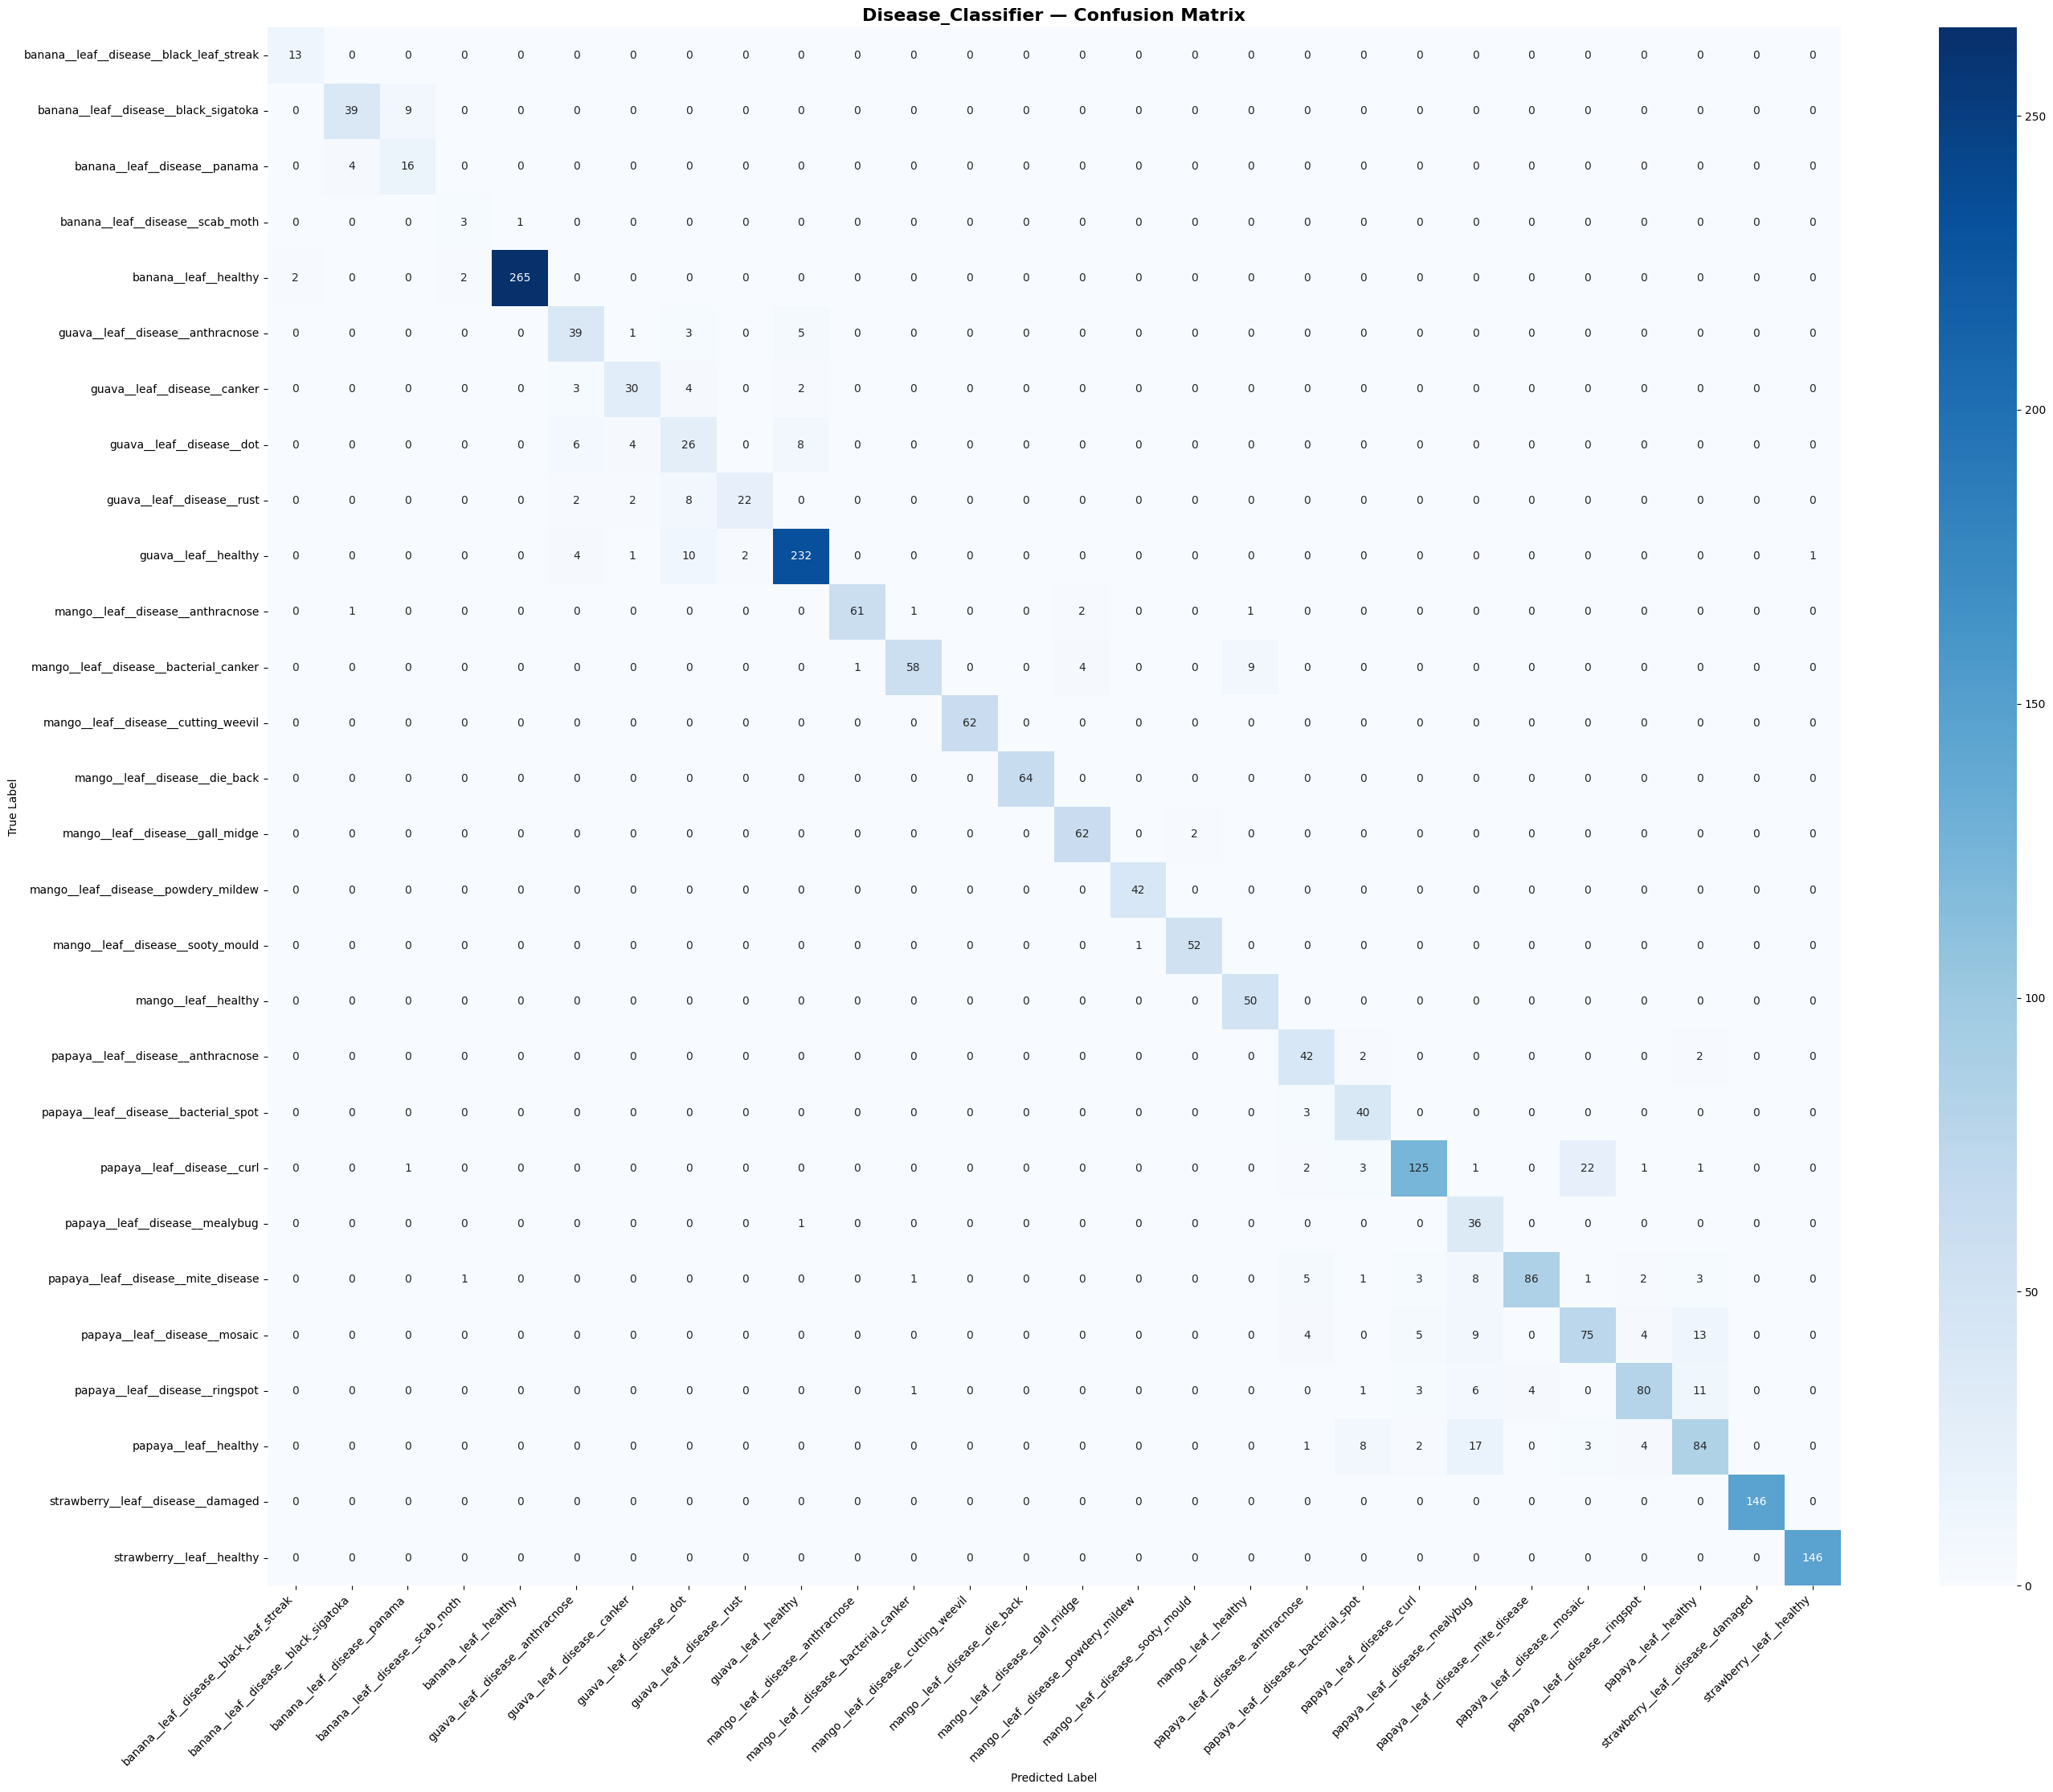


✅ Accuracy: 0.8824 (88.24%)

🎯 Disease Classifier Accuracy: 88.24%


In [11]:
def build_disease_classifier_model(config, num_classes):
    print("\n" + "="*70)
    print(f"Building Disease Classifier Model ({num_classes} classes)")
    print("="*70)
    base_model = tf.keras.applications.EfficientNetB1(
        input_shape=(*config.DISEASE_IMG_SIZE, 3), include_top=False, weights="imagenet")
    base_model.trainable = False

    inputs = keras.Input(shape=(*config.DISEASE_IMG_SIZE, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="disease_output")(x)

    model = keras.Model(inputs, outputs, name="disease_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.DISEASE_LR_INITIAL),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")])
    print(f"\u2713 Model built \u2014 Total params: {model.count_params():,}")
    return model


def unfreeze_disease(model, num_layers, learning_rate):
    """
    FIX: Recompile with FRESH metric objects to avoid
    'multiple values for argument sample_weight' TypeError in Keras 3.
    """
    print(f"\n\U0001f513 Unfreezing last {num_layers} layers...")
    base_model = next((l for l in model.layers if isinstance(l, keras.Model)), None)
    if base_model is None:
        print("\u26a0\ufe0f  Base model not found"); return model

    base_model.trainable = True
    for layer in base_model.layers[:-num_layers]:
        layer.trainable = False

    # KEY FIX: fresh metric instances — reusing old ones causes TypeError
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")])

    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"\u2713 Trainable params: {trainable:,}")
    return model


# ─────────────────────────────────────────────────────────────────────────────
_DISEASE_MODEL_PATH = os.path.join(config.WORKING_PATH, "disease_classifier_final.keras")

if os.path.exists(_DISEASE_MODEL_PATH):
    print("\u23ed\ufe0f  Disease model already trained \u2014 loading from disk.")
    disease_model = keras.models.load_model(_DISEASE_MODEL_PATH)
    disease_train, disease_val, disease_classes = load_dataset(
        DISEASE_PATH, config.DISEASE_IMG_SIZE, config.DISEASE_BATCH_SIZE,
        augment=False,
        preprocessing_fn=tf.keras.applications.efficientnet.preprocess_input)
    print(f"\u2713 Classes loaded: {len(disease_classes)}")
else:
    print("\n\U0001f4e6 Loading disease datasets...")
    disease_train, disease_val, disease_classes = load_dataset(
        DISEASE_PATH, config.DISEASE_IMG_SIZE, config.DISEASE_BATCH_SIZE,
        augment=True,
        preprocessing_fn=tf.keras.applications.efficientnet.preprocess_input)
    print(f"\u2713 Disease classes: {len(disease_classes)}")
    print(f"\u2713 Train batches: {len(disease_train)}  |  Val batches: {len(disease_val)}")

    # Save class names
    with open(os.path.join(config.WORKING_PATH, "disease_classes.json"), "w") as f:
        json.dump(disease_classes, f, indent=2)

    disease_model = build_disease_classifier_model(config, len(disease_classes))

    # Class weights from folder counts (avoids dataset iteration bug)
    train_dir = os.path.join(DISEASE_PATH, "train")
    class_folders = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    counts = {i: len(os.listdir(os.path.join(train_dir, cls))) for i, cls in enumerate(class_folders)}
    total  = sum(counts.values())
    n_cls  = len(counts)
    class_weights_disease = {i: total / (n_cls * cnt) for i, cnt in counts.items()}

    print(f"\n\U0001f4ca Class weights (from folder counts):")
    for i, w in class_weights_disease.items():
        print(f"  Class {i:2d} ({class_folders[i]}): {w:.4f}  [{counts[i]} images]")

    print("\n\U0001f680 Training disease classifier (Phase 1 \u2014 frozen base)...")
    history_d1 = disease_model.fit(
        disease_train, validation_data=disease_val,
        epochs=config.DISEASE_EPOCHS_INITIAL,
        callbacks=get_callbacks("disease_classifier", config),
        class_weight=class_weights_disease, verbose=1)

    print("\n\U0001f527 Fine-tuning disease classifier (Phase 2 \u2014 unfrozen)...")
    disease_model = unfreeze_disease(disease_model, 50, learning_rate=config.DISEASE_LR_FINETUNE)
    history_d2 = disease_model.fit(
        disease_train, validation_data=disease_val,
        epochs=config.DISEASE_EPOCHS_FINETUNE,
        callbacks=get_callbacks("disease_classifier_finetuned", config),
        class_weight=class_weights_disease, verbose=1)

    # Plot training curves
    plot_training_history(history_d1, history_d2, model_name="Disease_Classifier")

    disease_model.save(_DISEASE_MODEL_PATH)
    print(f"\n\u2705 Disease model saved \u2192 {_DISEASE_MODEL_PATH}")

# Evaluate
disease_accuracy, disease_report = evaluate_model(
    disease_model, disease_val, disease_classes, "Disease_Classifier")
print(f"\n\U0001f3af Disease Classifier Accuracy: {disease_accuracy*100:.2f}%")


---
## 🎉 Final Summary

In [12]:
print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)

saved_files = [
    "leaf_validator_final.keras",
    "disease_classifier_final.keras",
    "disease_classes.json",
    "Leaf_Validator_confusion_matrix.png",
    "Disease_Classifier_confusion_matrix.png",
    "Leaf_Validator_report.txt",
    "Disease_Classifier_report.txt",
]

print("\n💾 Output files (in /kaggle/working/):")
for fname in saved_files:
    full = os.path.join(config.WORKING_PATH, fname)
    status = "✅" if os.path.exists(full) else "❌ missing"
    print(f"  {status}  {fname}")

print("\n📥 Download models from the Output section on the right →")
print("="*70)



🎉 TRAINING COMPLETE!

💾 Output files (in /kaggle/working/):
  ✅  leaf_validator_final.keras
  ✅  disease_classifier_final.keras
  ✅  disease_classes.json
  ✅  Leaf_Validator_confusion_matrix.png
  ✅  Disease_Classifier_confusion_matrix.png
  ✅  Leaf_Validator_report.txt
  ✅  Disease_Classifier_report.txt

📥 Download models from the Output section on the right →
